# CST8508 Machine Vision - Lab 2 - Image Processing with OpenCV

**Objective:**
To provide students with practical experience in basic image processing techniques 
using OpenCV, reinforcing concepts from the initial lectures.

**Materials Required:**
- Computers with Python and OpenCV installed or Google Colab on web browser
- Sample images for processing

**Lab Duration:** 2 hours

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import urllib.request
import os

## Part 1: Histogram

Understanding the concept of image histogram

**Exercise 1:** Calculate and display the histogram of an image

In [2]:
def calculate_and_display_histogram(image_path):
    # Requirement: Calculate and display the histogram of an image
    # Load image from file path
    # 要求：计算并显示图像的直方图
    # 从文件路径加载图像
    img = cv2.imread(image_path)
    
    # Requirement: Calculate histogram for each color channel
    # OpenCV loads images in BGR format, so we calculate histograms for Blue, Green, Red channels
    # 要求：计算每个颜色通道的直方图
    # OpenCV 以 BGR 格式加载图像，因此我们计算蓝色、绿色、红色通道的直方图
    # Parameters: [image], [channels], [mask], [histSize], [ranges]
    # 参数：[图像], [通道], [掩码], [直方图大小], [范围]
    # histSize=256: number of bins (0-255 intensity levels)
    # ranges=[0,256]: pixel value range
    # histSize=256: 直方图箱数（0-255 强度级别）
    # ranges=[0,256]: 像素值范围
    colors = ('b', 'g', 'r')
    channel_names = ('Blue', 'Green', 'Red')
    
    # Requirement: Display the histogram
    # Visualize pixel intensity distribution for each color channel
    # 要求：显示直方图
    # 可视化每个颜色通道的像素强度分布
    plt.figure(figsize=(12, 5))
    
    # Display original image
    # 显示原始图像
    plt.subplot(1, 2, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for correct color display | 将 BGR 转换为 RGB 以正确显示颜色
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    # Display histogram for each channel
    # 显示每个通道的直方图
    plt.subplot(1, 2, 2)
    for i, (color, name) in enumerate(zip(colors, channel_names)):
        # Calculate histogram for channel i (0=Blue, 1=Green, 2=Red)
        # 计算通道 i 的直方图（0=蓝色, 1=绿色, 2=红色）
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=color, label=name)
    
    plt.title('Color Histogram')
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Frequency')
    plt.xlim([0, 256])
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Return histogram of all channels for verification
    # 返回所有通道的直方图用于验证
    img_histogram = [cv2.calcHist([img], [i], None, [256], [0, 256]) for i in range(3)]
    return img_histogram

## Part 2: Image Thresholding

Understanding different image thresholding techniques:
- Global Thresholding
- Adaptive Mean Thresholding
- Adaptive Gaussian Thresholding

**Exercise 2:** Convert an image from RGB to Grayscale and then apply global(binary), 
adaptive mean and adaptive gaussian thresholding and display the results.

In [3]:
def convert_to_grayscale_and_apply_threshold(image_path):
    # Requirement: Load and convert image to grayscale
    # Thresholding requires single-channel grayscale image
    # 要求：加载并转换图像为灰度图
    # 阈值处理需要单通道灰度图像
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Requirement: Apply global (binary) thresholding
    # Global threshold uses single value for entire image
    # 要求：应用全局（二值）阈值
    # 全局阈值对整个图像使用单一阈值
    # Pixels > 127 become 255 (white), others become 0 (black)
    # 像素值 > 127 变为 255（白色），其他变为 0（黑色）
    # Note: Works well for images with uniform lighting
    # Alternative: cv2.THRESH_OTSU for automatic threshold calculation
    # 注意：适用于光照均匀的图像
    # 替代方案：cv2.THRESH_OTSU 用于自动计算阈值
    _, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # Requirement: Apply adaptive mean thresholding
    # Adaptive threshold calculates different threshold for each image region
    # 要求：应用自适应均值阈值
    # 自适应阈值为每个图像区域计算不同的阈值
    # ADAPTIVE_THRESH_MEAN_C: threshold = mean of neighborhood area - C
    # ADAPTIVE_THRESH_MEAN_C: 阈值 = 邻域均值 - C
    # blockSize=11: size of neighborhood area (must be odd)
    # C=2: constant subtracted from mean
    # blockSize=11: 邻域区域大小（必须为奇数）
    # C=2: 从均值中减去的常数
    # Note: Better for images with varying lighting conditions
    # 注意：更适合光照变化的图像
    adaptive_mean_thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )
    
    # Requirement: Apply adaptive gaussian thresholding
    # Uses weighted sum (Gaussian window) instead of simple mean
    # 要求：应用自适应高斯阈值
    # 使用加权和（高斯窗口）而不是简单均值
    # ADAPTIVE_THRESH_GAUSSIAN_C: threshold = weighted sum of neighborhood - C
    # ADAPTIVE_THRESH_GAUSSIAN_C: 阈值 = 邻域加权和 - C
    # Note: Gaussian weights give more importance to nearby pixels
    # Alternative: Use different blockSize for different detail levels
    # 注意：高斯权重对邻近像素赋予更大权重
    # 替代方案：使用不同的 blockSize 以获得不同的细节级别
    adaptive_gaussian_thresh = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )
    
    # Requirement: Display all thresholding results
    # Compare different thresholding methods to understand their effects
    # 要求：显示所有阈值处理结果
    # 比较不同阈值方法以了解其效果
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].imshow(gray, cmap='gray')
    axes[0, 0].set_title('Original Grayscale')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(global_thresh, cmap='gray')
    axes[0, 1].set_title('Global Thresholding')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(adaptive_mean_thresh, cmap='gray')
    axes[1, 0].set_title('Adaptive Mean Thresholding')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(adaptive_gaussian_thresh, cmap='gray')
    axes[1, 1].set_title('Adaptive Gaussian Thresholding')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return global_thresh, adaptive_mean_thresh, adaptive_gaussian_thresh

## Part 3: Morphological Operations

Understanding different morphological operations:
- Erosion: Removes pixels from object boundaries
- Dilation: Adds pixels to object boundaries
- Opening: Erosion followed by Dilation (removes small noise)
- Closing: Dilation followed by Erosion (fills small holes)

**Exercise 3:** Convert an image to grayscale and perform each erosion, dilation, 
opening and closing operations. Display the results.

In [4]:
def process_image(image_path, kernel_size):
    # Requirement: Load and convert image to grayscale
    # Morphological operations work on binary or grayscale images
    # 要求：加载并转换图像为灰度图
    # 形态学操作适用于二值或灰度图像
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Requirement: Apply binary threshold to create binary image
    # Morphological operations are most effective on binary images
    # 要求：应用二值阈值创建二值图像
    # 形态学操作在二值图像上最有效
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # Requirement: Define kernel as a matrix of ones
    # Kernel (structuring element) determines the operation's neighborhood
    # 要求：定义核为全 1 矩阵
    # 核（结构元素）决定操作的邻域
    # kernel_size x kernel_size: size of the structuring element
    # np.uint8: data type for kernel
    # kernel_size x kernel_size: 结构元素的大小
    # np.uint8: 核的数据类型
    # Note: Larger kernel = stronger effect but may lose details
    # Alternative: cv2.getStructuringElement() for different shapes (RECT, ELLIPSE, CROSS)
    # 注意：更大的核 = 更强的效果但可能丢失细节
    # 替代方案：cv2.getStructuringElement() 用于不同形状（矩形、椭圆、十字）
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    
    # Requirement: Perform Dilation
    # Adds pixels to object boundaries, makes objects larger
    # 要求：执行膨胀操作
    # 向对象边界添加像素，使对象变大
    # Use case: Connect broken parts, fill small gaps
    # 使用场景：连接断开的部分，填充小间隙
    dilated_img = cv2.dilate(binary, kernel, iterations=1)
    
    # Requirement: Perform Erosion
    # Removes pixels from object boundaries, makes objects smaller
    # 要求：执行腐蚀操作
    # 从对象边界移除像素，使对象变小
    # Use case: Remove small noise, separate connected objects
    # 使用场景：移除小噪声，分离连接的对象
    eroded_img = cv2.erode(binary, kernel, iterations=1)
    
    # Requirement: Perform Opening (Erosion followed by Dilation)
    # Removes small white noise while preserving object shape
    # 要求：执行开运算（先腐蚀后膨胀）
    # 移除小的白色噪声同时保持对象形状
    # MORPH_OPEN: erosion removes noise, dilation restores object size
    # MORPH_OPEN: 腐蚀移除噪声，膨胀恢复对象大小
    # Note: Effective for removing small bright spots on dark background
    # 注意：有效移除暗背景上的小亮点
    opened_img = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    
    # Requirement: Perform Closing (Dilation followed by Erosion)
    # Fills small holes while preserving object shape
    # 要求：执行闭运算（先膨胀后腐蚀）
    # 填充小孔洞同时保持对象形状
    # MORPH_CLOSE: dilation fills holes, erosion restores object size
    # MORPH_CLOSE: 膨胀填充孔洞，腐蚀恢复对象大小
    # Note: Effective for filling small dark holes in bright objects
    # Alternative: Use multiple iterations for stronger effect
    # 注意：有效填充亮对象中的小暗孔
    # 替代方案：使用多次迭代以获得更强效果
    closed_img = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    
    # Requirement: Display all morphological operation results
    # Compare different operations to understand their effects
    # 要求：显示所有形态学操作结果
    # 比较不同操作以了解其效果
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(gray, cmap='gray')
    axes[0, 0].set_title('Original Grayscale')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(binary, cmap='gray')
    axes[0, 1].set_title('Binary Image')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(dilated_img, cmap='gray')
    axes[0, 2].set_title('Dilation (Expand)')
    axes[0, 2].axis('off')
    
    axes[1, 0].imshow(eroded_img, cmap='gray')
    axes[1, 0].set_title('Erosion (Shrink)')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(opened_img, cmap='gray')
    axes[1, 1].set_title('Opening (Remove Noise)')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(closed_img, cmap='gray')
    axes[1, 2].set_title('Closing (Fill Holes)')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return dilated_img, eroded_img, opened_img, closed_img

## Setup: Download Sample Image

Download a sample image for testing all exercises

In [5]:
# Download sample image from OpenCV repository
# 从 OpenCV 仓库下载示例图像
image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
image_path = 'sample_image.jpg'

try:
    # Download and save image locally
    # 下载并保存图像到本地
    urllib.request.urlretrieve(image_url, image_path)
    print(f'Downloaded image to {image_path}')
    print(f'File exists: {os.path.exists(image_path)}')
except Exception as e:
    print(f'Error downloading image: {e}')

Downloaded image to sample_image.jpg
File exists: True


## Test Exercise 1: Histogram

Calculate and display the histogram of the sample image

Exercise 1: Histogram


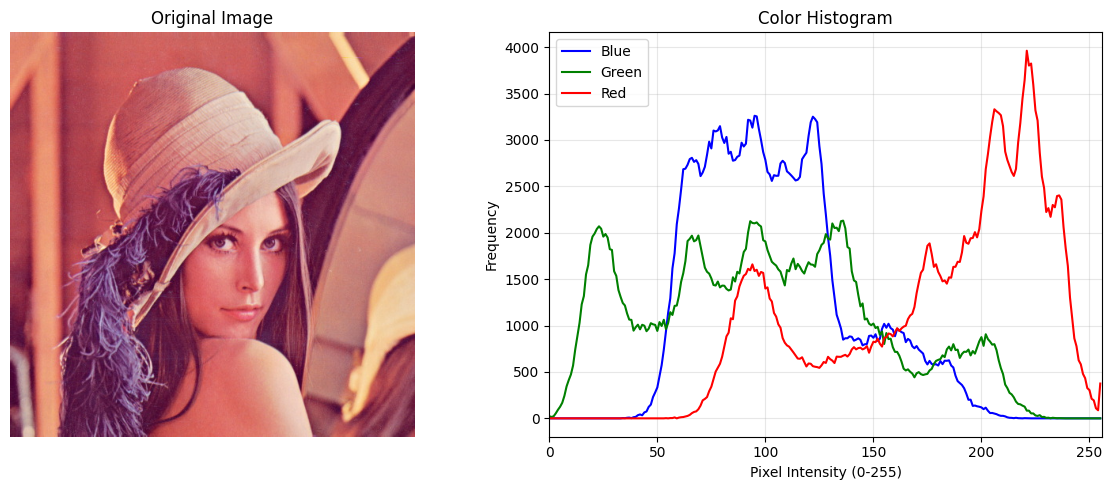

Number of channels: 3
Histogram shape per channel: (256, 1)
Exercise 1 completed successfully


In [6]:
# Test Exercise 1: Calculate and display histogram
# 测试练习 1：计算并显示直方图
print('Exercise 1: Histogram')
try:
    histogram = calculate_and_display_histogram(image_path)
    print(f'Number of channels: {len(histogram)}')
    print(f'Histogram shape per channel: {histogram[0].shape}')
    print('Exercise 1 completed successfully')
except Exception as e:
    print(f'Error in Exercise 1: {e}')

## Test Exercise 2: Image Thresholding

Apply and compare different thresholding techniques

Exercise 2: Image Thresholding


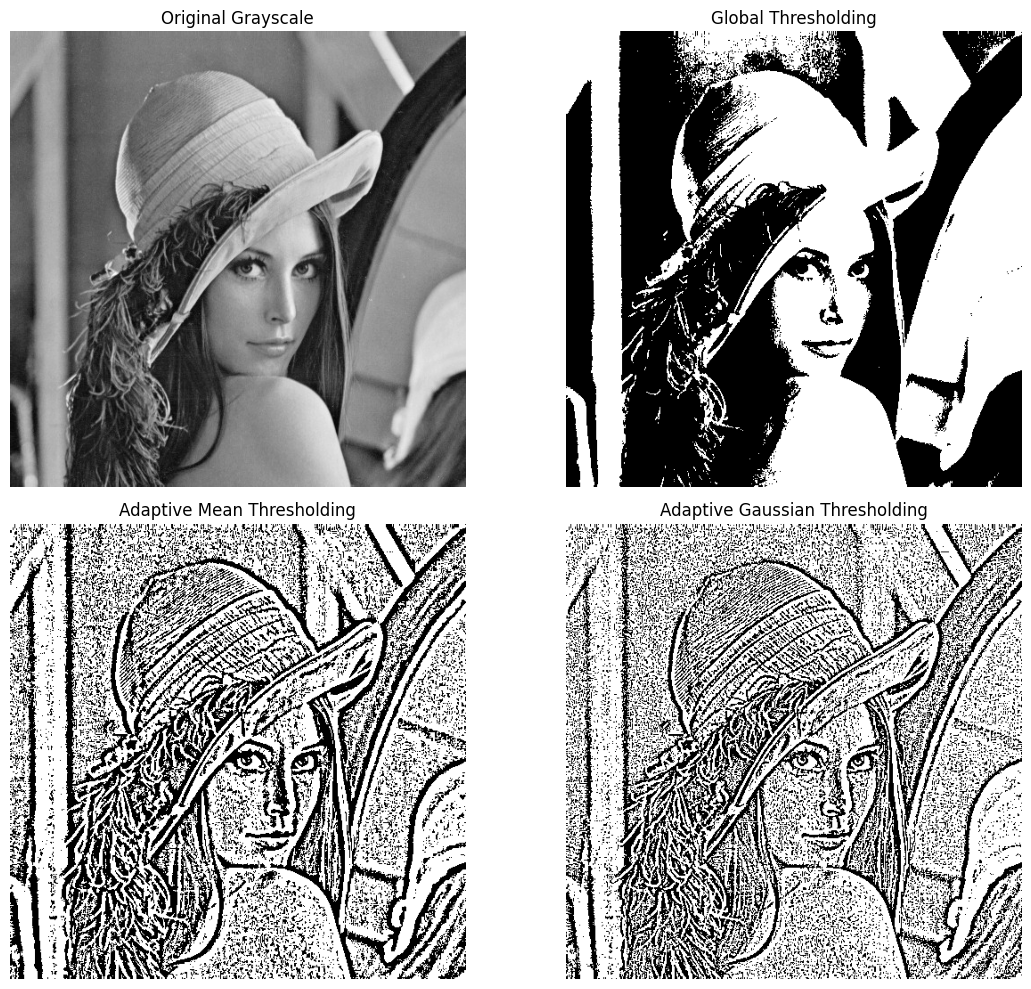

Global threshold size: (512, 512)
Adaptive mean threshold size: (512, 512)
Adaptive gaussian threshold size: (512, 512)
Exercise 2 completed successfully


In [7]:
# Test Exercise 2: Apply different thresholding techniques
# 测试练习 2：应用不同的阈值技术
print('Exercise 2: Image Thresholding')
try:
    global_t, adaptive_mean_t, adaptive_gaussian_t = convert_to_grayscale_and_apply_threshold(image_path)
    print(f'Global threshold size: {global_t.shape}')
    print(f'Adaptive mean threshold size: {adaptive_mean_t.shape}')
    print(f'Adaptive gaussian threshold size: {adaptive_gaussian_t.shape}')
    print('Exercise 2 completed successfully')
except Exception as e:
    print(f'Error in Exercise 2: {e}')

## Test Exercise 3: Morphological Operations

Apply and visualize different morphological operations

Exercise 3: Morphological Operations


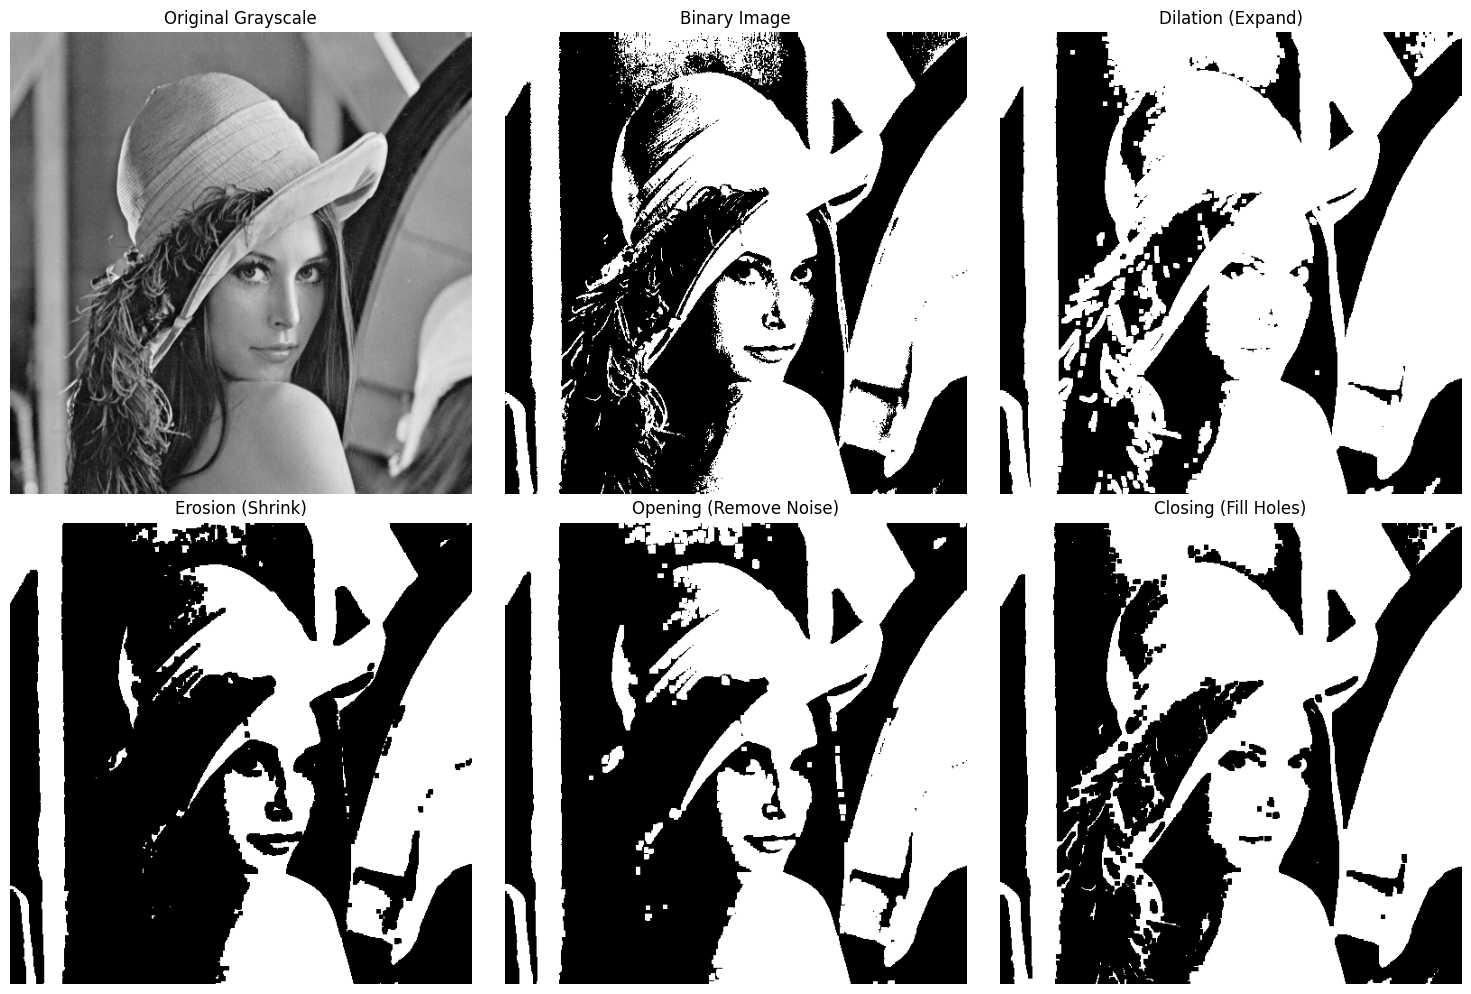

Dilated image size: (512, 512)
Eroded image size: (512, 512)
Opened image size: (512, 512)
Closed image size: (512, 512)
Exercise 3 completed successfully


In [8]:
# Test Exercise 3: Apply morphological operations
# 测试练习 3：应用形态学操作
print('Exercise 3: Morphological Operations')
try:
    dilated, eroded, opened, closed = process_image(image_path, kernel_size=5)
    print(f'Dilated image size: {dilated.shape}')
    print(f'Eroded image size: {eroded.shape}')
    print(f'Opened image size: {opened.shape}')
    print(f'Closed image size: {closed.shape}')
    print('Exercise 3 completed successfully')
except Exception as e:
    print(f'Error in Exercise 3: {e}')
